Fitting 5 folds for each of 20 candidates, totalling 100 fits

--- SVR Continuous Performance ---
MAE:  6.0195
RMSE: 9.5623
R2:   0.7216

Weighted F1-Score: 0.9127

                                precision    recall  f1-score   support

                          Good       0.93      0.93      0.93       737
                          Fair       0.88      0.89      0.88       429
Unhealthy for Sensitive Groups       1.00      0.50      0.67         2

                      accuracy                           0.91      1168
                     macro avg       0.94      0.77      0.83      1168
                  weighted avg       0.91      0.91      0.91      1168



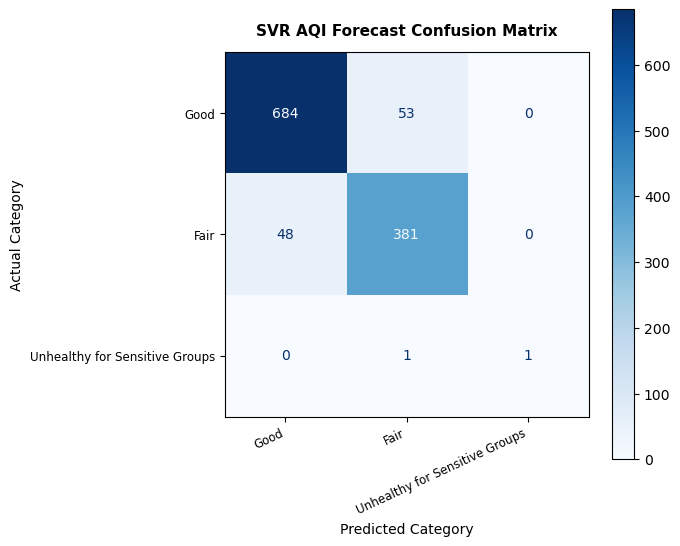

NameError: name 'artifact' is not defined

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    ConfusionMatrixDisplay, classification_report, confusion_matrix, 
    mean_absolute_error, r2_score, root_mean_squared_error, f1_score
)
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

# 1. Load Data & Engineer Features (Identical to XGBoost)
df = pd.read_csv('augmented_pollutant_data.csv', low_memory=False)
df.rename(columns={'date': 'Date', 'aqi': 'AQI'}, inplace=True)
df = df.dropna(subset=['Date', 'AQI']).copy()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

df['sin_doy'] = np.sin(2 * np.pi * df['Date'].dt.dayofyear / 365.25)
df['cos_doy'] = np.cos(2 * np.pi * df['Date'].dt.dayofyear / 365.25)
df['sin_dow'] = np.sin(2 * np.pi * df['Date'].dt.dayofweek / 7)
df['cos_dow'] = np.cos(2 * np.pi * df['Date'].dt.dayofweek / 7)

pollutants = ['pm2.5', 'pm10', 'so2', 'nox', 'o3', 'co']
time_features = ['sin_doy', 'cos_doy', 'sin_dow', 'cos_dow']

FORECAST_HORIZON = 1
df['target_AQI'] = df['AQI'].shift(-FORECAST_HORIZON)

for lag in [0, 1, 2, 3]:
    df[f'aqi_lag{lag}'] = df['AQI'].shift(lag)

df['aqi_diff_1'] = df['AQI'].diff(1)
df['aqi_rolling_mean_7'] = df['AQI'].rolling(window=7).mean()
df['aqi_rolling_std_7'] = df['AQI'].rolling(window=7).std()

lag_cols = []
for p in pollutants:
    for lag in [0, 1]:
        col_name = f'{p}_lag{lag}'
        df[col_name] = df[p].shift(lag)
        lag_cols.append(col_name)

feature_cols = ['aqi_lag0', 'aqi_lag1', 'aqi_lag2', 'aqi_lag3', 'aqi_diff_1', 'aqi_rolling_mean_7', 'aqi_rolling_std_7'] + lag_cols + time_features
df = df.dropna(subset=['target_AQI', 'aqi_rolling_std_7']).reset_index(drop=True)

# 2. Train-Test Split & Imputation
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

train_medians = train_df[feature_cols].median()
train_df[feature_cols] = train_df[feature_cols].ffill().fillna(train_medians)
test_df[feature_cols] = test_df[feature_cols].ffill().fillna(train_medians)

X_train, y_train = train_df[feature_cols], train_df['target_AQI']
X_test, y_test = test_df[feature_cols], test_df['target_AQI']

# -------------------------------------------------------------
# 3. Strict Train-Fitted Scaling (CRITICAL FOR SVR)
# -------------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Hyperparameter Search
param_distributions = {
    'C': [0.1, 1.0, 10.0, 100.0],
    'gamma': ['scale', 'auto', 0.01, 0.1],
    'epsilon': [0.1, 0.5, 1.0, 2.0, 5.0]
}

base_svr = SVR(kernel='rbf')
tscv = TimeSeriesSplit(n_splits=5)

tune_search = RandomizedSearchCV(
    estimator=base_svr, param_distributions=param_distributions,
    n_iter=20, scoring='neg_root_mean_squared_error',
    cv=tscv, random_state=42, n_jobs=-1, verbose=1
)
tune_search.fit(X_train_scaled, y_train)
best_svr = tune_search.best_estimator_

# -------------------------------------------------------------
# 5. Continuous Evaluation (R2 Score)
# -------------------------------------------------------------
y_pred = best_svr.predict(X_test_scaled)
print('\n--- SVR Continuous Performance ---')
print(f'MAE:  {mean_absolute_error(y_test, y_pred):.4f}')
print(f'RMSE: {root_mean_squared_error(y_test, y_pred):.4f}')
print(f'R2:   {r2_score(y_test, y_pred):.4f}') # Explicit R2 Print

# -------------------------------------------------------------
# 6. Classification & F1 Score
# -------------------------------------------------------------
CATEGORY_BINS = [-np.inf, 50, 100, 150, 200, 300, np.inf]
CATEGORY_LABELS = ['Good', 'Fair', 'Unhealthy for Sensitive Groups', 'Very Unhealthy', 'Acutely Unhealthy', 'Emergency']

y_test_cat = pd.cut(y_test, bins=CATEGORY_BINS, labels=CATEGORY_LABELS, right=True).astype(str)
y_pred_cat = pd.cut(y_pred, bins=CATEGORY_BINS, labels=CATEGORY_LABELS, right=True).astype(str)
present_labels = [label for label in CATEGORY_LABELS if (y_test_cat == label).any()]

weighted_f1 = f1_score(y_test_cat, y_pred_cat, labels=present_labels, average='weighted', zero_division=0)
print(f'\nWeighted F1-Score: {weighted_f1:.4f}\n') # Explicit F1 Print
print(classification_report(y_test_cat, y_pred_cat, labels=present_labels, zero_division=0))

# -------------------------------------------------------------
# 7. Confusion Matrix Plot
# -------------------------------------------------------------
cm = confusion_matrix(y_test_cat, y_pred_cat, labels=present_labels)
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=present_labels)
disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title('SVR AQI Forecast Confusion Matrix', fontsize=11, fontweight='bold', pad=12)
plt.ylabel('Actual Category', fontsize=10)
plt.xlabel('Predicted Category', fontsize=10)
plt.xticks(rotation=25, ha='right', fontsize=8.5)
plt.yticks(fontsize=8.5)
plt.tight_layout()
plt.savefig('svr_AQI_confusion_matrix.png', dpi=300)
plt.show()

import joblib
joblib.dump(artifact, 'augmented_fine_tuned_svm_AQI_forecast_pipeline.joblib')
print('\nSaved pipeline and metadata bundle to _augmented_fine_tuned_svm_AQI_forecast_pipeline.joblib')